# Species Accumulation Curves with PanTHERIA Body-Mass Thresholds
## Global Point-Buffer Method (SSUSA vs IUCN)

This notebook uses **1 km deployment point-buffers** to compare Snapshot USA
observed species against IUCN predicted species, filtered by **PanTHERIA
adult body mass** thresholds.

Deployment point-buffers are then aggregated to **camera-trap arrays** before
running the species accumulation curves.

Each threshold produces **separate** global comparison tables,
array-level SAC figures, and one final cross-threshold overlay figure.

**Default thresholds**: Unfiltered baseline, >= 50 g, >= 100 g, >= 1000 g
(configurable in the parameter block below).

In [5]:
import os

# Must set R path BEFORE importing rpy2
conda_env_path = "/home/hice1/kyan66/scratch/r_kernel"
os.environ['R_HOME'] = f"{conda_env_path}/lib/R"
os.environ['PATH'] = f"{conda_env_path}/bin:" + os.environ.get('PATH', '')
os.environ['LD_LIBRARY_PATH'] = f"{conda_env_path}/lib:" + os.environ.get('LD_LIBRARY_PATH', '')
print(f"R environment path configured: {os.environ['R_HOME']}")

R environment path configured: /home/hice1/kyan66/scratch/r_kernel/lib/R


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import random
import re
import geopandas as gpd

In [7]:
save_dir = '../data/ssusa'
os.makedirs(save_dir, exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

random.seed(42)
np.random.seed(42)

In [8]:
# ==============================================================================
# PARAMETER BLOCK  --  edit these values to change all downstream outputs
# ==============================================================================

# Mass thresholds in grams.  None = unfiltered baseline.
mass_thresholds = [None, 50, 100, 1000]

# Point-buffer radius (km) around each camera deployment
point_buffer_km = 1.0

# File paths
iucn_path      = "../data/MAMMALS_TERRESTRIAL_ONLY/MAMMALS_TERRESTRIAL_ONLY.shp"
ssusa_path     = "../data/ssusa/cleaned_snapshot_usa_iucn.csv"
pantheria_path = "../data/PanTHERIA_1-0_WR05_Aug2008.txt"

# SAC settings
sac_permutations = 100   # number of permutations for method='random'

def threshold_label(t):
    """Human-readable label for a mass threshold."""
    return "Unfiltered (all species)" if t is None else f">= {t} g"

def threshold_filesafe(t):
    """File-safe string for a threshold (used in output filenames)."""
    return "unfiltered" if t is None else f"{t}g"

In [9]:
df = pd.read_csv(ssusa_path, low_memory=False)
print(f"SSUSA records loaded: {len(df)}")
df.head()

SSUSA records loaded: 698887


,Year,Project,Camera_Trap_Array,Deployment_ID,Sequence_ID,Start_Time,End_Time,Class,Order,Family,Genus,Species,Common_Name,Sci_Name,Age,Sex,Group_Size,Site_Name,Start_Date,End_Date,Survey_Nights,Latitude,Longitude,Habitat,Development_Level,Feature_Type
0,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s1,2019-08-31 06:50:00,2019-08-31 06:50:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,unknown,unknown,1,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source
1,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s2,2019-08-31 14:15:00,2019-08-31 14:17:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,unknown,unknown,1,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source
2,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s3,2019-08-31 18:22:00,2019-08-31 18:22:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,unknown,unknown,1,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source
3,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s4,2019-08-31 20:58:00,2019-08-31 20:58:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,adult,female,1,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source
4,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s4,2019-08-31 20:58:00,2019-08-31 20:58:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,juvenile,unknown,2,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source


In [10]:
def _pick_column(columns, candidates):
    """Return the first matching column name (case-insensitive)."""
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def _normalize_species(value):
    """Lowercase, trim, collapse whitespace."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    text = str(value).strip()
    text = re.sub(r"\s+", " ", text).lower()
    return text

In [11]:
def get_species_matrix(df, unit_col, species_col='Sci_Name', all_units=None):
    """Binary presence/absence matrix (sampling-unit x species)."""
    valid_data = df.dropna(subset=[unit_col]).copy()
    valid_data = valid_data.dropna(subset=[species_col])
    valid_data = valid_data[valid_data[species_col] != ""]

    matrix = pd.crosstab(valid_data[unit_col], valid_data[species_col])
    matrix = (matrix > 0).astype(int)

    if all_units is not None:
        unit_index = pd.Index(pd.Series(all_units).dropna().tolist(), name=unit_col).unique()
        matrix = matrix.reindex(unit_index, fill_value=0)

    if matrix.index.name is None:
        matrix.index.name = unit_col

    return matrix.sort_index()


def build_global_comparison(snapshot_df, iucn_df, species_col='Sci_Name'):
    """Build the global overlap table for one threshold."""
    snapshot_global = (
        snapshot_df[[species_col]]
        .dropna()
        .drop_duplicates()
        .rename(columns={species_col: 'species'})
    )
    snapshot_global['in_snapshot'] = True

    iucn_global = (
        iucn_df[[species_col]]
        .dropna()
        .drop_duplicates()
        .rename(columns={species_col: 'species'})
    )
    iucn_global['in_iucn'] = True

    global_joint = snapshot_global.merge(iucn_global, on='species', how='outer', sort=True)
    if global_joint.empty:
        return pd.DataFrame(columns=['species', 'in_snapshot', 'in_iucn', 'category'])

    global_joint['in_snapshot'] = global_joint['in_snapshot'].fillna(False).astype(bool)
    global_joint['in_iucn'] = global_joint['in_iucn'].fillna(False).astype(bool)
    global_joint['category'] = np.select(
        [
            global_joint['in_snapshot'] & global_joint['in_iucn'],
            global_joint['in_snapshot'] & ~global_joint['in_iucn'],
            ~global_joint['in_snapshot'] & global_joint['in_iucn'],
        ],
        ['both', 'snapshot_only', 'iucn_only'],
        default='unknown',
    )

    category_order = pd.Categorical(
        global_joint['category'],
        categories=['both', 'snapshot_only', 'iucn_only', 'unknown'],
        ordered=True,
    )
    global_joint['category'] = category_order
    global_joint = global_joint.sort_values(['category', 'species']).reset_index(drop=True)
    global_joint['category'] = global_joint['category'].astype(str)
    return global_joint


def species_accumulation(matrix, method='exact', permutations=100,
                         conditioned=True, gamma='jack1', w=None):
    """Wrapper around R vegan::specaccum."""
    vegan = importr('vegan')
    with localconverter(pandas2ri.converter + robjects.default_converter):
        r_matrix = pandas2ri.py2rpy(matrix)
        kwargs = {
            'method': method,
            'permutations': permutations,
            'conditioned': conditioned,
            'gamma': gamma
        }
        if w is not None:
            kwargs['w'] = robjects.FloatVector(w)
        result = vegan.specaccum(r_matrix, **kwargs)

    with localconverter(pandas2ri.converter + robjects.default_converter):
        sites = np.array(robjects.r('as.numeric')(result.rx2('sites')))
        richness = np.array(robjects.r('as.numeric')(result.rx2('richness')))
        try:
            sd_val = result.rx2('sd')
            sd = np.array(robjects.r('as.numeric')(sd_val)) if sd_val != robjects.NULL else np.zeros_like(richness)
        except Exception:
            sd = np.zeros_like(richness)
    return {'sites': sites, 'richness': richness, 'sd': sd, 'method': method}


def plot_threshold_sac(acc_obs, acc_iucn, n_units, n_sp_obs, n_sp_iucn,
                       label, buffer_km):
    """Observed-vs-IUCN SAC figure for one threshold."""
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
    plt.style.use('seaborn-v0_8-whitegrid')

    x1, y1, sd1 = acc_obs['sites'], acc_obs['richness'], acc_obs['sd']
    me1 = max(1, len(x1) // 30)
    if sd1 is not None and np.any(sd1 > 0):
        ax.fill_between(x1, y1 - 2 * sd1, y1 + 2 * sd1,
                        color='#2E7D32', alpha=0.15)
    ax.plot(x1, y1, color='#2E7D32', linewidth=3,
            marker='o', markersize=4, markerfacecolor='white',
            markeredgewidth=2, markeredgecolor='#2E7D32',
            markevery=me1,
            label='Observed Species (SSUSA Detections)', zorder=3)

    x2, y2, sd2 = acc_iucn['sites'], acc_iucn['richness'], acc_iucn['sd']
    me2 = max(1, len(x2) // 30)
    if sd2 is not None and np.any(sd2 > 0):
        ax.fill_between(x2, y2 - 2 * sd2, y2 + 2 * sd2,
                        color='#6A1B9A', alpha=0.15)
    ax.plot(x2, y2, color='#6A1B9A', linewidth=3, linestyle='--',
            marker='s', markersize=4, markerfacecolor='white',
            markeredgewidth=2, markeredgecolor='#6A1B9A',
            markevery=me2,
            label='IUCN Expected Species (Point Buffers)', zorder=3)

    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel('Sampling Units (Arrays)', fontsize=16,
                  fontweight='bold', labelpad=12)
    ax.set_ylabel('Accumulated Species Richness', fontsize=16,
                  fontweight='bold', labelpad=12)
    ax.set_title(f'Species Accumulation Curves [{label}]\n'
                 f'({buffer_km} km deployment point buffers, array-level)',
                 fontsize=18, fontweight='bold', pad=20)
    ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=2)

    legend = ax.legend(loc='lower right', frameon=True, fancybox=True,
                       shadow=True, fontsize=13, framealpha=0.97,
                       edgecolor='#333333', facecolor='white')
    legend.get_frame().set_linewidth(1.5)

    textstr = (f'Arrays: {n_units}\n'
               f'Observed: {n_sp_obs} species\n'
               f'IUCN: {n_sp_iucn} species')
    props = dict(boxstyle='round,pad=0.8', facecolor='white',
                 edgecolor='#333333', linewidth=1.5, alpha=0.95)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('#333333')

    plt.tight_layout()
    plt.show()

    print(f"\n  Observed richness : {acc_obs['richness'][-1]:.0f}")
    print(f"  IUCN richness     : {acc_iucn['richness'][-1]:.0f}")
    print(f"  Detection gap     : "
          f"{acc_iucn['richness'][-1] - acc_obs['richness'][-1]:.0f} species")


def plot_threshold_overlay(curve_results, buffer_km):
    """Overlay observed and IUCN SAC curves for all thresholds in one plot."""
    fig, ax = plt.subplots(figsize=(15, 8), dpi=300)
    plt.style.use('seaborn-v0_8-whitegrid')

    threshold_colors = {
        'Unfiltered (all species)': '#1B9E77',
        '>= 50 g': '#D95F02',
        '>= 100 g': '#7570B3',
        '>= 1000 g': '#E7298A',
    }

    for result in curve_results:
        color = threshold_colors.get(result['label'], '#4C78A8')
        acc_obs = result['acc_obs']
        acc_iucn = result['acc_iucn']

        obs_markevery = max(1, len(acc_obs['sites']) // 24)
        iucn_markevery = max(1, len(acc_iucn['sites']) // 24)

        ax.plot(
            acc_obs['sites'],
            acc_obs['richness'],
            color=color,
            linewidth=2.5,
            marker='o',
            markersize=4,
            markerfacecolor='white',
            markeredgewidth=1.5,
            markeredgecolor=color,
            markevery=obs_markevery,
            label=f"Observed | {result['label']}",
            zorder=3,
        )
        ax.plot(
            acc_iucn['sites'],
            acc_iucn['richness'],
            color=color,
            linewidth=2.5,
            linestyle='--',
            marker='s',
            markersize=4,
            markerfacecolor='white',
            markeredgewidth=1.5,
            markeredgecolor=color,
            markevery=iucn_markevery,
            label=f"IUCN | {result['label']}",
            zorder=3,
        )

    n_units = curve_results[0]['n_units'] if curve_results else 0
    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel('Sampling Units (Arrays)', fontsize=16,
                  fontweight='bold', labelpad=12)
    ax.set_ylabel('Accumulated Species Richness', fontsize=16,
                  fontweight='bold', labelpad=12)
    ax.set_title(f'Species Accumulation Curves Across Mass Thresholds\n'
                 f'({buffer_km} km deployment point buffers, array-level)',
                 fontsize=18, fontweight='bold', pad=20)
    ax.tick_params(axis='both', which='major', labelsize=13, length=7, width=2)

    legend = ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fancybox=True,
        shadow=True,
        fontsize=10,
        edgecolor='#333333',
        facecolor='white',
    )
    legend.get_frame().set_linewidth(1.5)

    textstr = (f'Arrays: {n_units}\n'
               f'Solid = Observed\n'
               f'Dashed = IUCN')
    props = dict(boxstyle='round,pad=0.8', facecolor='white',
                 edgecolor='#333333', linewidth=1.5, alpha=0.95)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('#333333')

    plt.tight_layout(rect=[0, 0, 0.78, 1])
    plt.show()

In [12]:
# ----------------------------
# Load PanTHERIA dataset
# ----------------------------
pantheria = pd.read_csv(pantheria_path, sep="\t")
pantheria = pantheria.replace(-999, np.nan)
pantheria = pantheria.replace(-999.00, np.nan)

# Keep only species name and body mass
pantheria = pantheria[["MSW05_Binomial", "5-1_AdultBodyMass_g"]].copy()
pantheria.columns = ["Sci_Name_pantheria", "Adult_Body_Mass_g"]

# Normalize species names
pantheria["Sci_Name_pantheria"] = pantheria["Sci_Name_pantheria"].map(
    _normalize_species
)
pantheria = pantheria.drop_duplicates(subset=["Sci_Name_pantheria"])

print(f"PanTHERIA species loaded: {len(pantheria)}")
print(f"  with body mass  : {pantheria['Adult_Body_Mass_g'].notna().sum()}")
print(f"  missing body mass: {pantheria['Adult_Body_Mass_g'].isna().sum()}")
pantheria.head()

PanTHERIA species loaded: 5416
  with body mass  : 3542
  missing body mass: 1874


,Sci_Name_pantheria,Adult_Body_Mass_g
0,camelus dromedarius,492714.47
1,canis adustus,10392.49
2,canis aureus,9658.70
3,canis latrans,11989.10
4,canis lupus,31756.51


In [13]:
# ----------------------------
# Taxonomy harmonization (SSUSA / IUCN -> current names; current names -> PanTHERIA MSW05)
# ----------------------------
taxonomy_remap = {
    'mustela frenata': 'neogale frenata',
    'myodes gapperi': 'clethrionomys gapperi',
    'neovison vison': 'neogale vison',
    'pekania pennanti': 'martes pennanti',
}
pantheria_name_map = {new_name: old_name for old_name, new_name in taxonomy_remap.items()}


def harmonize_taxonomy(name):
    """Map SSUSA / IUCN species names to the current comparison taxonomy."""
    if name is None:
        return None
    return taxonomy_remap.get(name, name)


def pantheria_lookup_name(name):
    """Map current comparison names back to PanTHERIA MSW05 names."""
    if name is None:
        return None
    return pantheria_name_map.get(name, name)


def get_eligible_species(threshold, all_species, pantheria_df):
    """Return the set of species passing a mass threshold.

    Rules
    -----
    * threshold=None  ->  keep all species (unfiltered baseline).
    * Otherwise       ->  keep if Adult_Body_Mass_g >= threshold
                          OR body mass is missing (NaN).
    """
    if threshold is None:
        print(f"  Threshold: Unfiltered -- all {len(all_species)} species retained")
        return set(all_species)

    species_df = pd.DataFrame({'species': sorted(all_species)})
    species_df['pantheria_key'] = species_df['species'].map(pantheria_lookup_name)

    merged = species_df.merge(
        pantheria_df,
        left_on='pantheria_key',
        right_on='Sci_Name_pantheria',
        how='left',
    )

    keep = merged['Adult_Body_Mass_g'].isna() | (merged['Adult_Body_Mass_g'] >= threshold)
    eligible = set(merged.loc[keep, 'species'])

    n_by_mass = int((merged['Adult_Body_Mass_g'] >= threshold).sum())
    n_missing = int(merged['Adult_Body_Mass_g'].isna().sum())
    n_removed = len(all_species) - len(eligible)

    print(f"  Threshold: >= {threshold} g")
    print(f"    Retained by mass       : {n_by_mass}")
    print(f"    Retained (mass missing): {n_missing}")
    print(f"    Removed (below thresh) : {n_removed}")
    print(f"    Total eligible         : {len(eligible)} / {len(all_species)}")
    return eligible

In [14]:
# ----------------------------
# Load IUCN species range data
# ----------------------------
iucn = gpd.read_file(iucn_path)
if iucn.crs is None:
    iucn = iucn.set_crs("EPSG:4326")
else:
    iucn = iucn.to_crs("EPSG:4326")

iucn = iucn[iucn.geometry.notnull()].copy()
if not iucn.is_valid.all():
    iucn["geometry"] = iucn.geometry.buffer(0)

print(f"IUCN polygons loaded: {len(iucn)}")

IUCN polygons loaded: 12703


In [15]:
# ----------------------------
# Align species naming between IUCN and Snapshot USA
# ----------------------------
# IUCN species column
iucn_species_col = _pick_column(
    iucn.columns,
    ['SCI_NAME', 'Sci_Name', 'binomial', 'scientific', 'species', 'Species'],
)
if iucn_species_col is None:
    raise ValueError('Could not detect IUCN species name column.')

iucn['Sci_Name'] = iucn[iucn_species_col].map(_normalize_species).map(harmonize_taxonomy)
iucn = iucn.dropna(subset=['Sci_Name'])
iucn = iucn[['Sci_Name', 'geometry']]

# SSUSA species column
df_species_col = _pick_column(
    df.columns,
    ['Sci_Name', 'SciName', 'Scientific_Name', 'species', 'Species'],
)
if df_species_col is None:
    raise ValueError('Could not detect SSUSA species column.')
if df_species_col != 'Sci_Name':
    df['Sci_Name'] = df[df_species_col]
df['Sci_Name'] = df['Sci_Name'].map(_normalize_species).map(harmonize_taxonomy)

print(f"IUCN unique species : {iucn['Sci_Name'].nunique()}")
print(f"SSUSA unique species: {df['Sci_Name'].nunique()}")

IUCN unique species : 5683
SSUSA unique species: 113


In [16]:
# ----------------------------
# Remove non-native / domestic species from IUCN ranges
# ----------------------------
species_removed_snapshot = [
    'boselaphus tragocamelus', 'lama glama', 'lariscus insignis',
    'oryx gazella', 'urva javanica', 'sus scrofa',
    'canis lupus familiaris', 'felis catus', 'bos taurus', 'equus caballus',
    'ovis aries', 'sus scrofa domesticus', 'capra hircus', 'equus asinus',
    'rattus norvegicus', 'rattus rattus', 'mus musculus',
]
species_removed_set = set(
    pd.Series(species_removed_snapshot).str.lower().str.strip().tolist()
)

iucn = iucn[~iucn["Sci_Name"].isin(species_removed_set)].copy()
print(f"IUCN species after non-native removal: {iucn['Sci_Name'].nunique()}")

IUCN species after non-native removal: 5675


In [17]:
# ----------------------------
# Build deployment points and point-buffer spatial join
# ----------------------------
lat_col = _pick_column(df.columns, ['Latitude', 'Lat', 'GPS_Latitude'])
lon_col = _pick_column(df.columns, ['Longitude', 'Lon', 'GPS_Longitude'])
array_col = _pick_column(df.columns, ['Camera_Trap_Array', 'Array', 'Array_ID'])
deployment_col = _pick_column(
    df.columns,
    ['Deployment_ID', 'Deployment', 'DeploymentID', 'Site_Name'],
)

if lat_col is None or lon_col is None or array_col is None or deployment_col is None:
    raise ValueError('Missing required columns for lat/lon/array/deployment.')

# Detection-level records with valid coordinates
df_points = df.dropna(subset=[lat_col, lon_col, deployment_col]).copy()
df_points[lat_col] = pd.to_numeric(df_points[lat_col], errors='coerce')
df_points[lon_col] = pd.to_numeric(df_points[lon_col], errors='coerce')
df_points = df_points.dropna(subset=[lat_col, lon_col])

in_range = df_points[lat_col].between(-90, 90) & df_points[lon_col].between(-180, 180)
df_points = df_points[in_range].copy()

# One point and one buffer per deployment for the spatial workflow
deployment_points = (
    df_points[[deployment_col, array_col, lat_col, lon_col]]
    .drop_duplicates(subset=[deployment_col])
    .sort_values(deployment_col)
    .reset_index(drop=True)
)
all_deployments = deployment_points[deployment_col].tolist()
all_arrays = sorted(deployment_points[array_col].dropna().unique().tolist())

gdf_deployments = gpd.GeoDataFrame(
    deployment_points,
    geometry=gpd.points_from_xy(deployment_points[lon_col], deployment_points[lat_col]),
    crs='EPSG:4326',
)
gdf_deployments_m = gdf_deployments.to_crs(3857)

gdf_point_buffers_m = gdf_deployments_m[[deployment_col, array_col, 'geometry']].copy()
gdf_point_buffers_m['geometry'] = gdf_point_buffers_m.geometry.buffer(point_buffer_km * 1000.0)
gdf_point_buffers_m = gdf_point_buffers_m[gdf_point_buffers_m.geometry.notna()].copy()

print(f"Detection records with valid coordinates : {len(df_points)}")
print(f"Unique arrays                            : {deployment_points[array_col].nunique()}")
print(f"Unique deployments                       : {len(all_deployments)}")
print(f"Point buffers ({point_buffer_km} km)                 : {len(gdf_point_buffers_m)}")

# Spatial join: IUCN polygons x deployment point buffers
iucn_m = iucn.to_crs(3857)
iucn_m = iucn_m[iucn_m.geometry.notnull()].copy()

iucn_in_point_buffers = gpd.sjoin(
    iucn_m,
    gdf_point_buffers_m,
    how='inner',
    predicate='intersects',
)
iucn_in_point_buffers = (
    iucn_in_point_buffers[[deployment_col, array_col, 'Sci_Name']]
    .dropna(subset=[deployment_col, 'Sci_Name'])
    .drop_duplicates()
    .reset_index(drop=True)
)

if iucn_in_point_buffers.empty:
    raise ValueError('No IUCN polygons intersected deployment buffers.')

print(f"IUCN-buffer deployment hits             : {len(iucn_in_point_buffers)}")
print(f"IUCN species in deployment buffers      : {iucn_in_point_buffers['Sci_Name'].nunique()}")

Detection records with valid coordinates : 698887
Unique arrays                            : 261
Unique deployments                       : 9255
Point buffers (1.0 km)                 : 9255
IUCN-buffer deployment hits             : 416880
IUCN species in deployment buffers      : 303


# Mass-Threshold Analysis

For each threshold in the parameter block, the workflow below:
1. Filters species by PanTHERIA adult body mass and keeps species with missing mass.
2. Builds a global SSUSA vs IUCN comparison table with both, snapshot_only, and iucn_only.
3. Builds array-level presence/absence matrices for observed and IUCN species.
4. Draws four standalone Observed vs IUCN SAC figures, one per threshold.
5. Draws one final overlay SAC figure combining all thresholds in a single plot.


MASS THRESHOLD: Unfiltered (all species)
  Threshold: Unfiltered -- all 311 species retained

  Global comparison (Unfiltered (all species)):
    both          : 105
    snapshot_only : 8
    iucn_only     : 198


,species,in_snapshot,in_iucn,category
0,alces alces,True,True,both
1,ammospermophilus harrisii,True,True,both
2,ammospermophilus leucurus,True,True,both
3,antilocapra americana,True,True,both
4,aplodontia rufa,True,True,both
...,...,...,...,...
306,urocitellus elegans,False,True,iucn_only
307,urocitellus mollis,False,True,iucn_only
308,xerospermophilus spilosoma,False,True,iucn_only
309,zapus princeps,False,True,iucn_only


  Saved to ../data/ssusa/global_comparison_unfiltered.csv

  Observed matrix : 261 arrays x 113 species
  IUCN matrix     : 261 arrays x 303 species


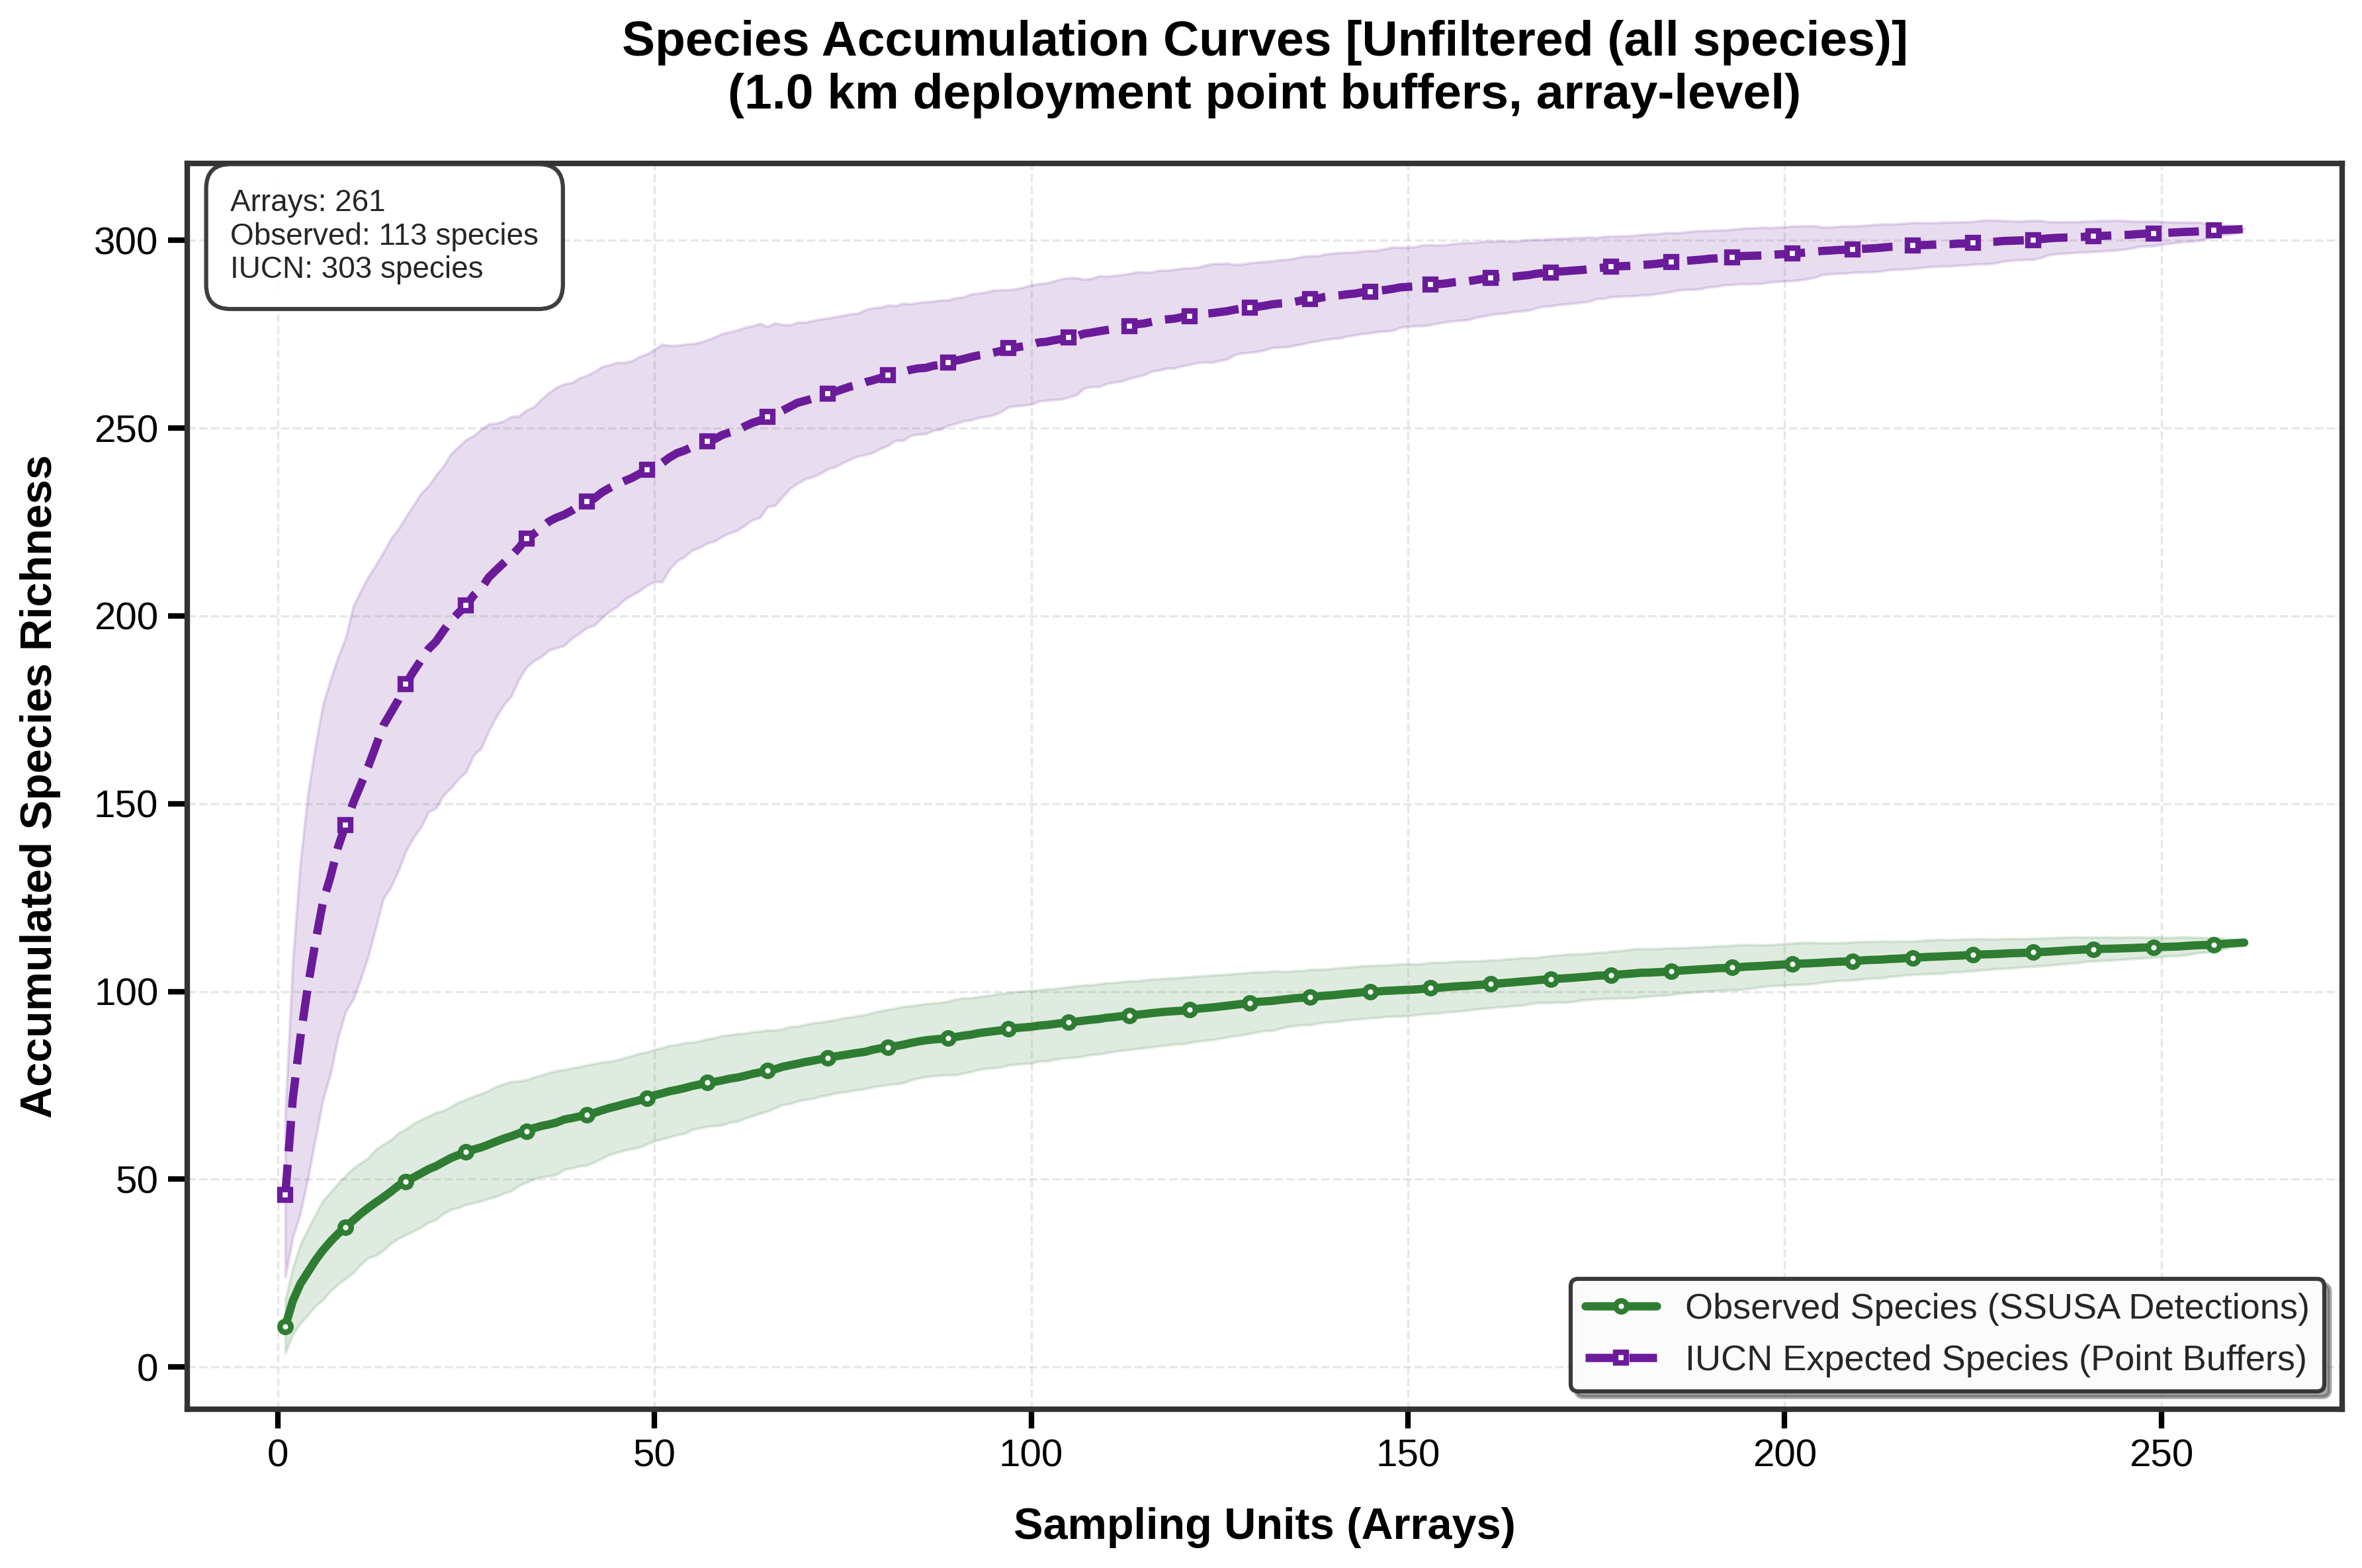


  Observed richness : 113
  IUCN richness     : 303
  Detection gap     : 190 species

MASS THRESHOLD: >= 50 g
  Threshold: >= 50 g
    Retained by mass       : 123
    Retained (mass missing): 63
    Removed (below thresh) : 125
    Total eligible         : 186 / 311

  Global comparison (>= 50 g):
    both          : 93
    snapshot_only : 8
    iucn_only     : 85


,species,in_snapshot,in_iucn,category
0,alces alces,True,True,both
1,ammospermophilus harrisii,True,True,both
2,ammospermophilus leucurus,True,True,both
3,antilocapra americana,True,True,both
4,aplodontia rufa,True,True,both
...,...,...,...,...
181,urocitellus canus,False,True,iucn_only
182,urocitellus columbianus,False,True,iucn_only
183,urocitellus elegans,False,True,iucn_only
184,urocitellus mollis,False,True,iucn_only


  Saved to ../data/ssusa/global_comparison_50g.csv

  Observed matrix : 261 arrays x 101 species
  IUCN matrix     : 261 arrays x 178 species


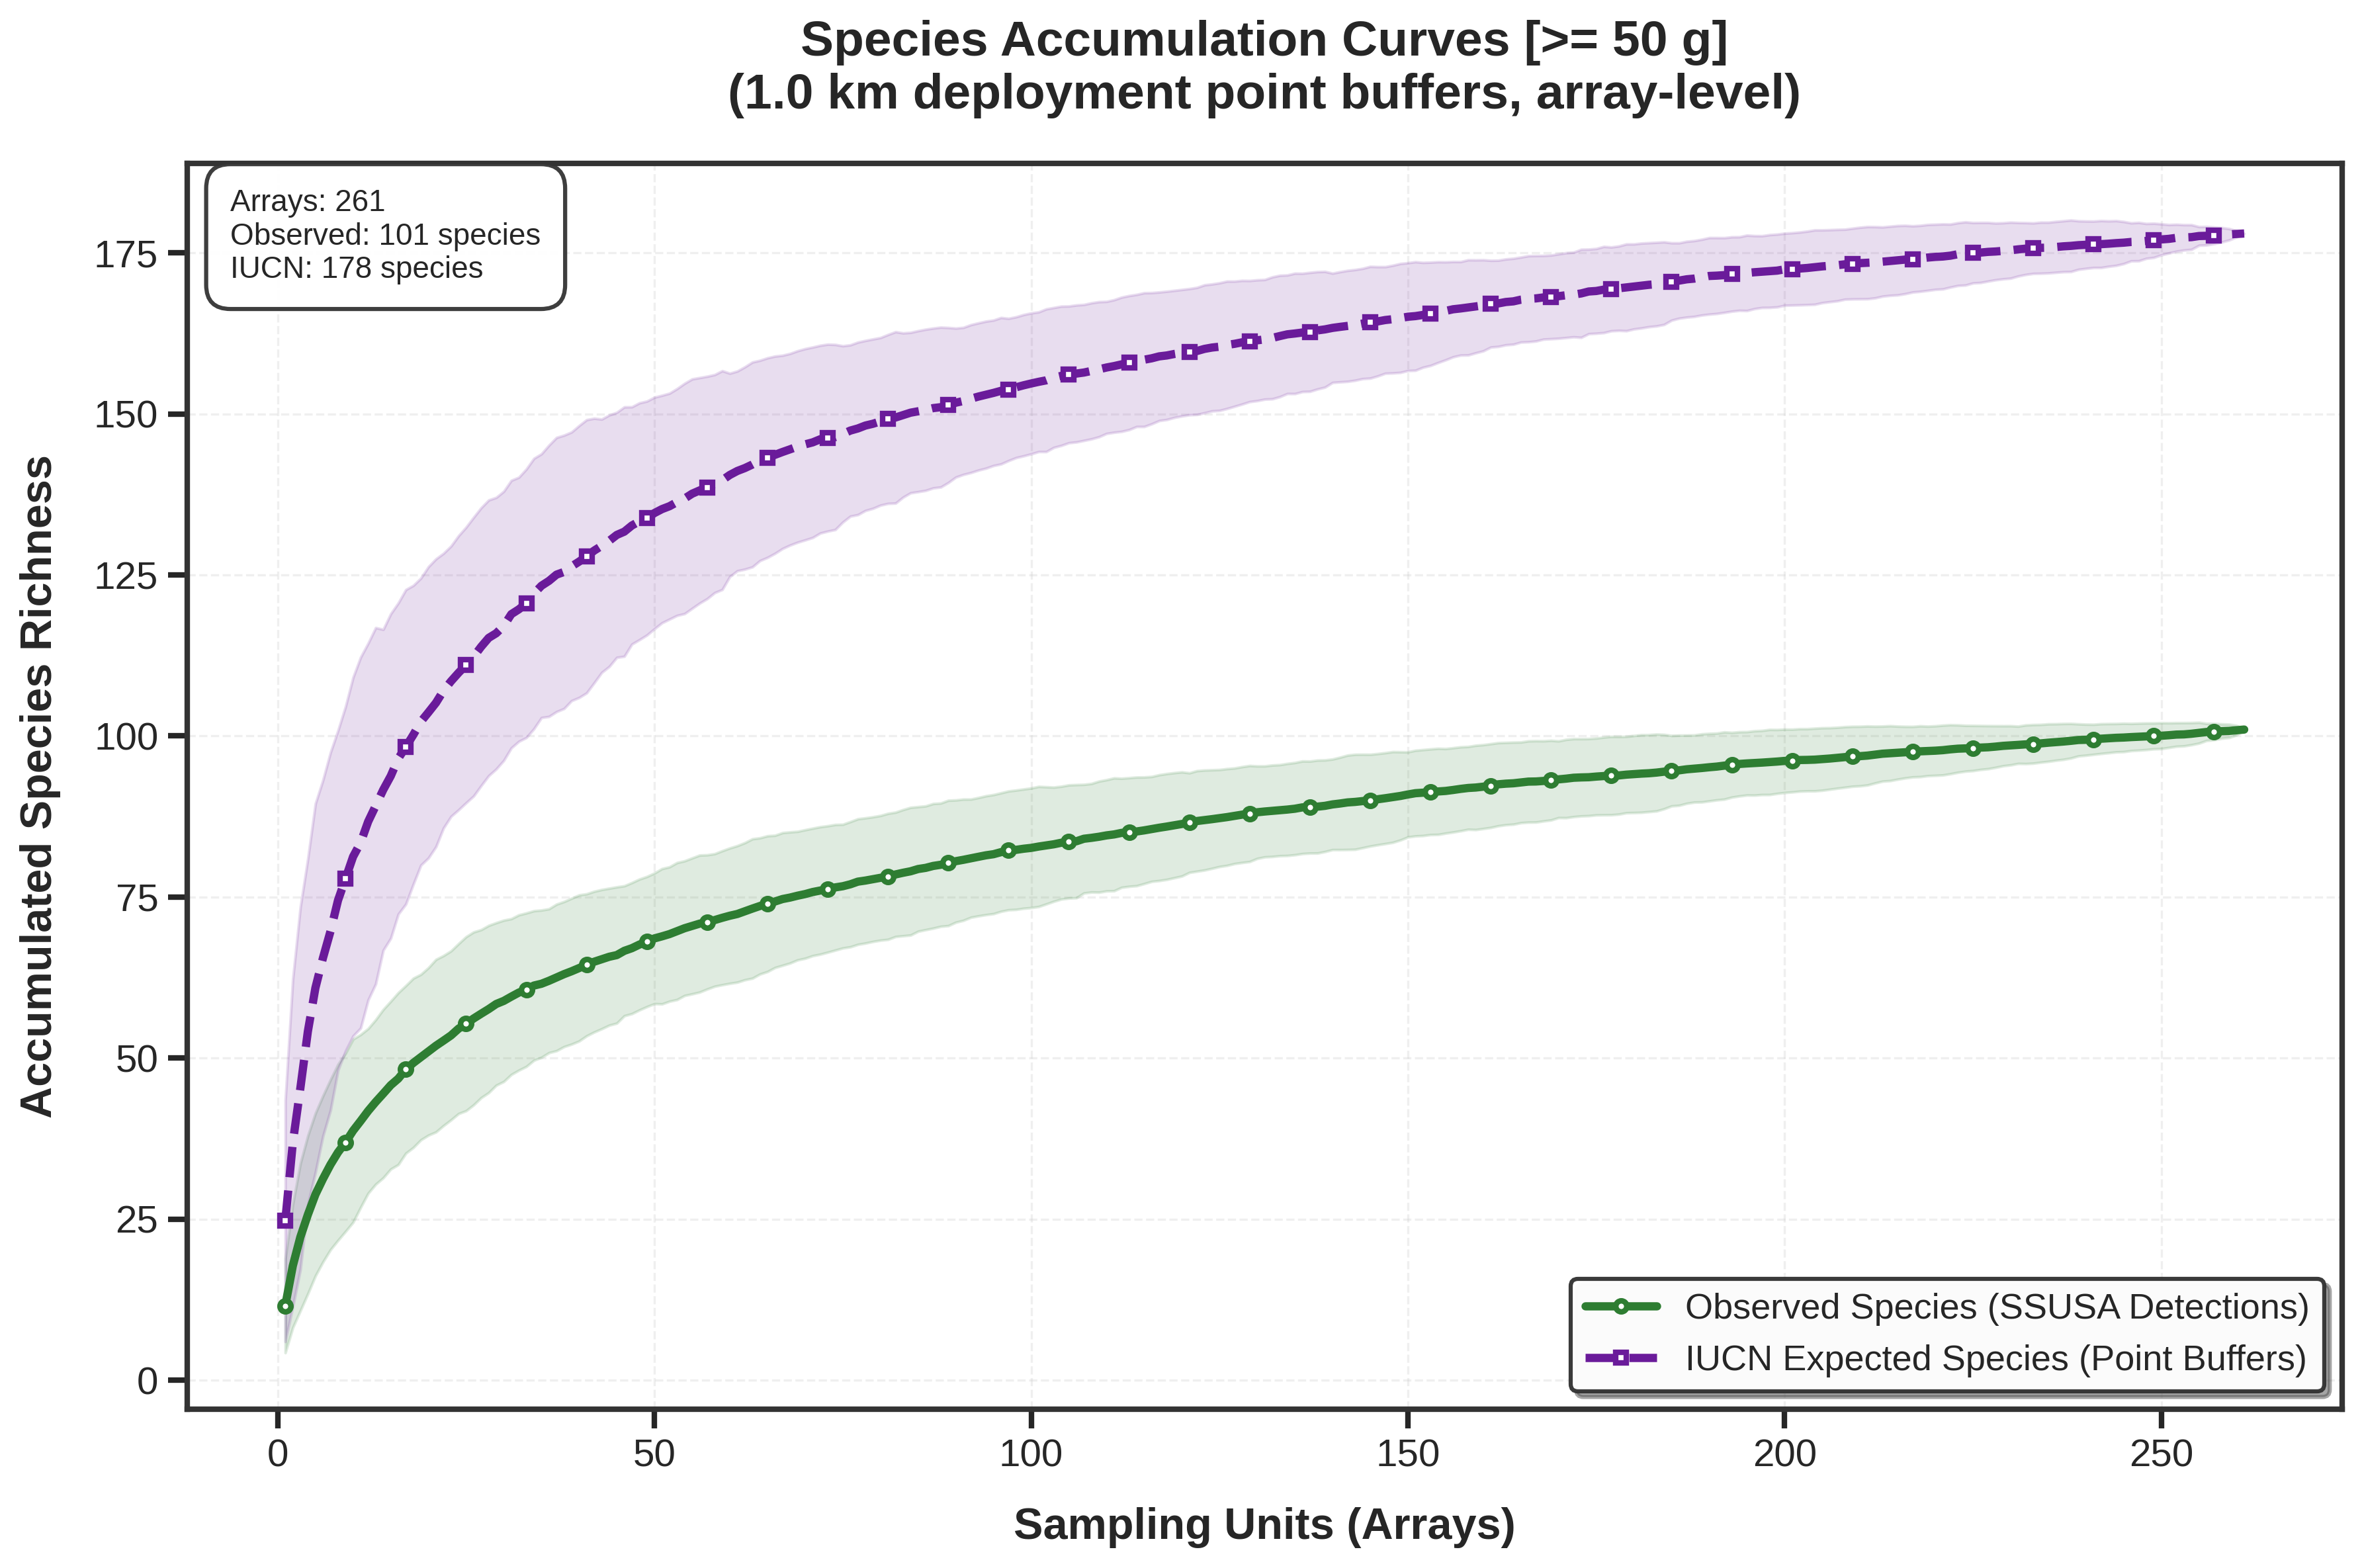


  Observed richness : 101
  IUCN richness     : 178
  Detection gap     : 77 species

MASS THRESHOLD: >= 100 g
  Threshold: >= 100 g
    Retained by mass       : 103
    Retained (mass missing): 63
    Removed (below thresh) : 145
    Total eligible         : 166 / 311

  Global comparison (>= 100 g):
    both          : 91
    snapshot_only : 8
    iucn_only     : 67


,species,in_snapshot,in_iucn,category
0,alces alces,True,True,both
1,ammospermophilus harrisii,True,True,both
2,ammospermophilus leucurus,True,True,both
3,antilocapra americana,True,True,both
4,aplodontia rufa,True,True,both
...,...,...,...,...
161,urocitellus canus,False,True,iucn_only
162,urocitellus columbianus,False,True,iucn_only
163,urocitellus elegans,False,True,iucn_only
164,urocitellus mollis,False,True,iucn_only


  Saved to ../data/ssusa/global_comparison_100g.csv

  Observed matrix : 261 arrays x 99 species
  IUCN matrix     : 261 arrays x 158 species


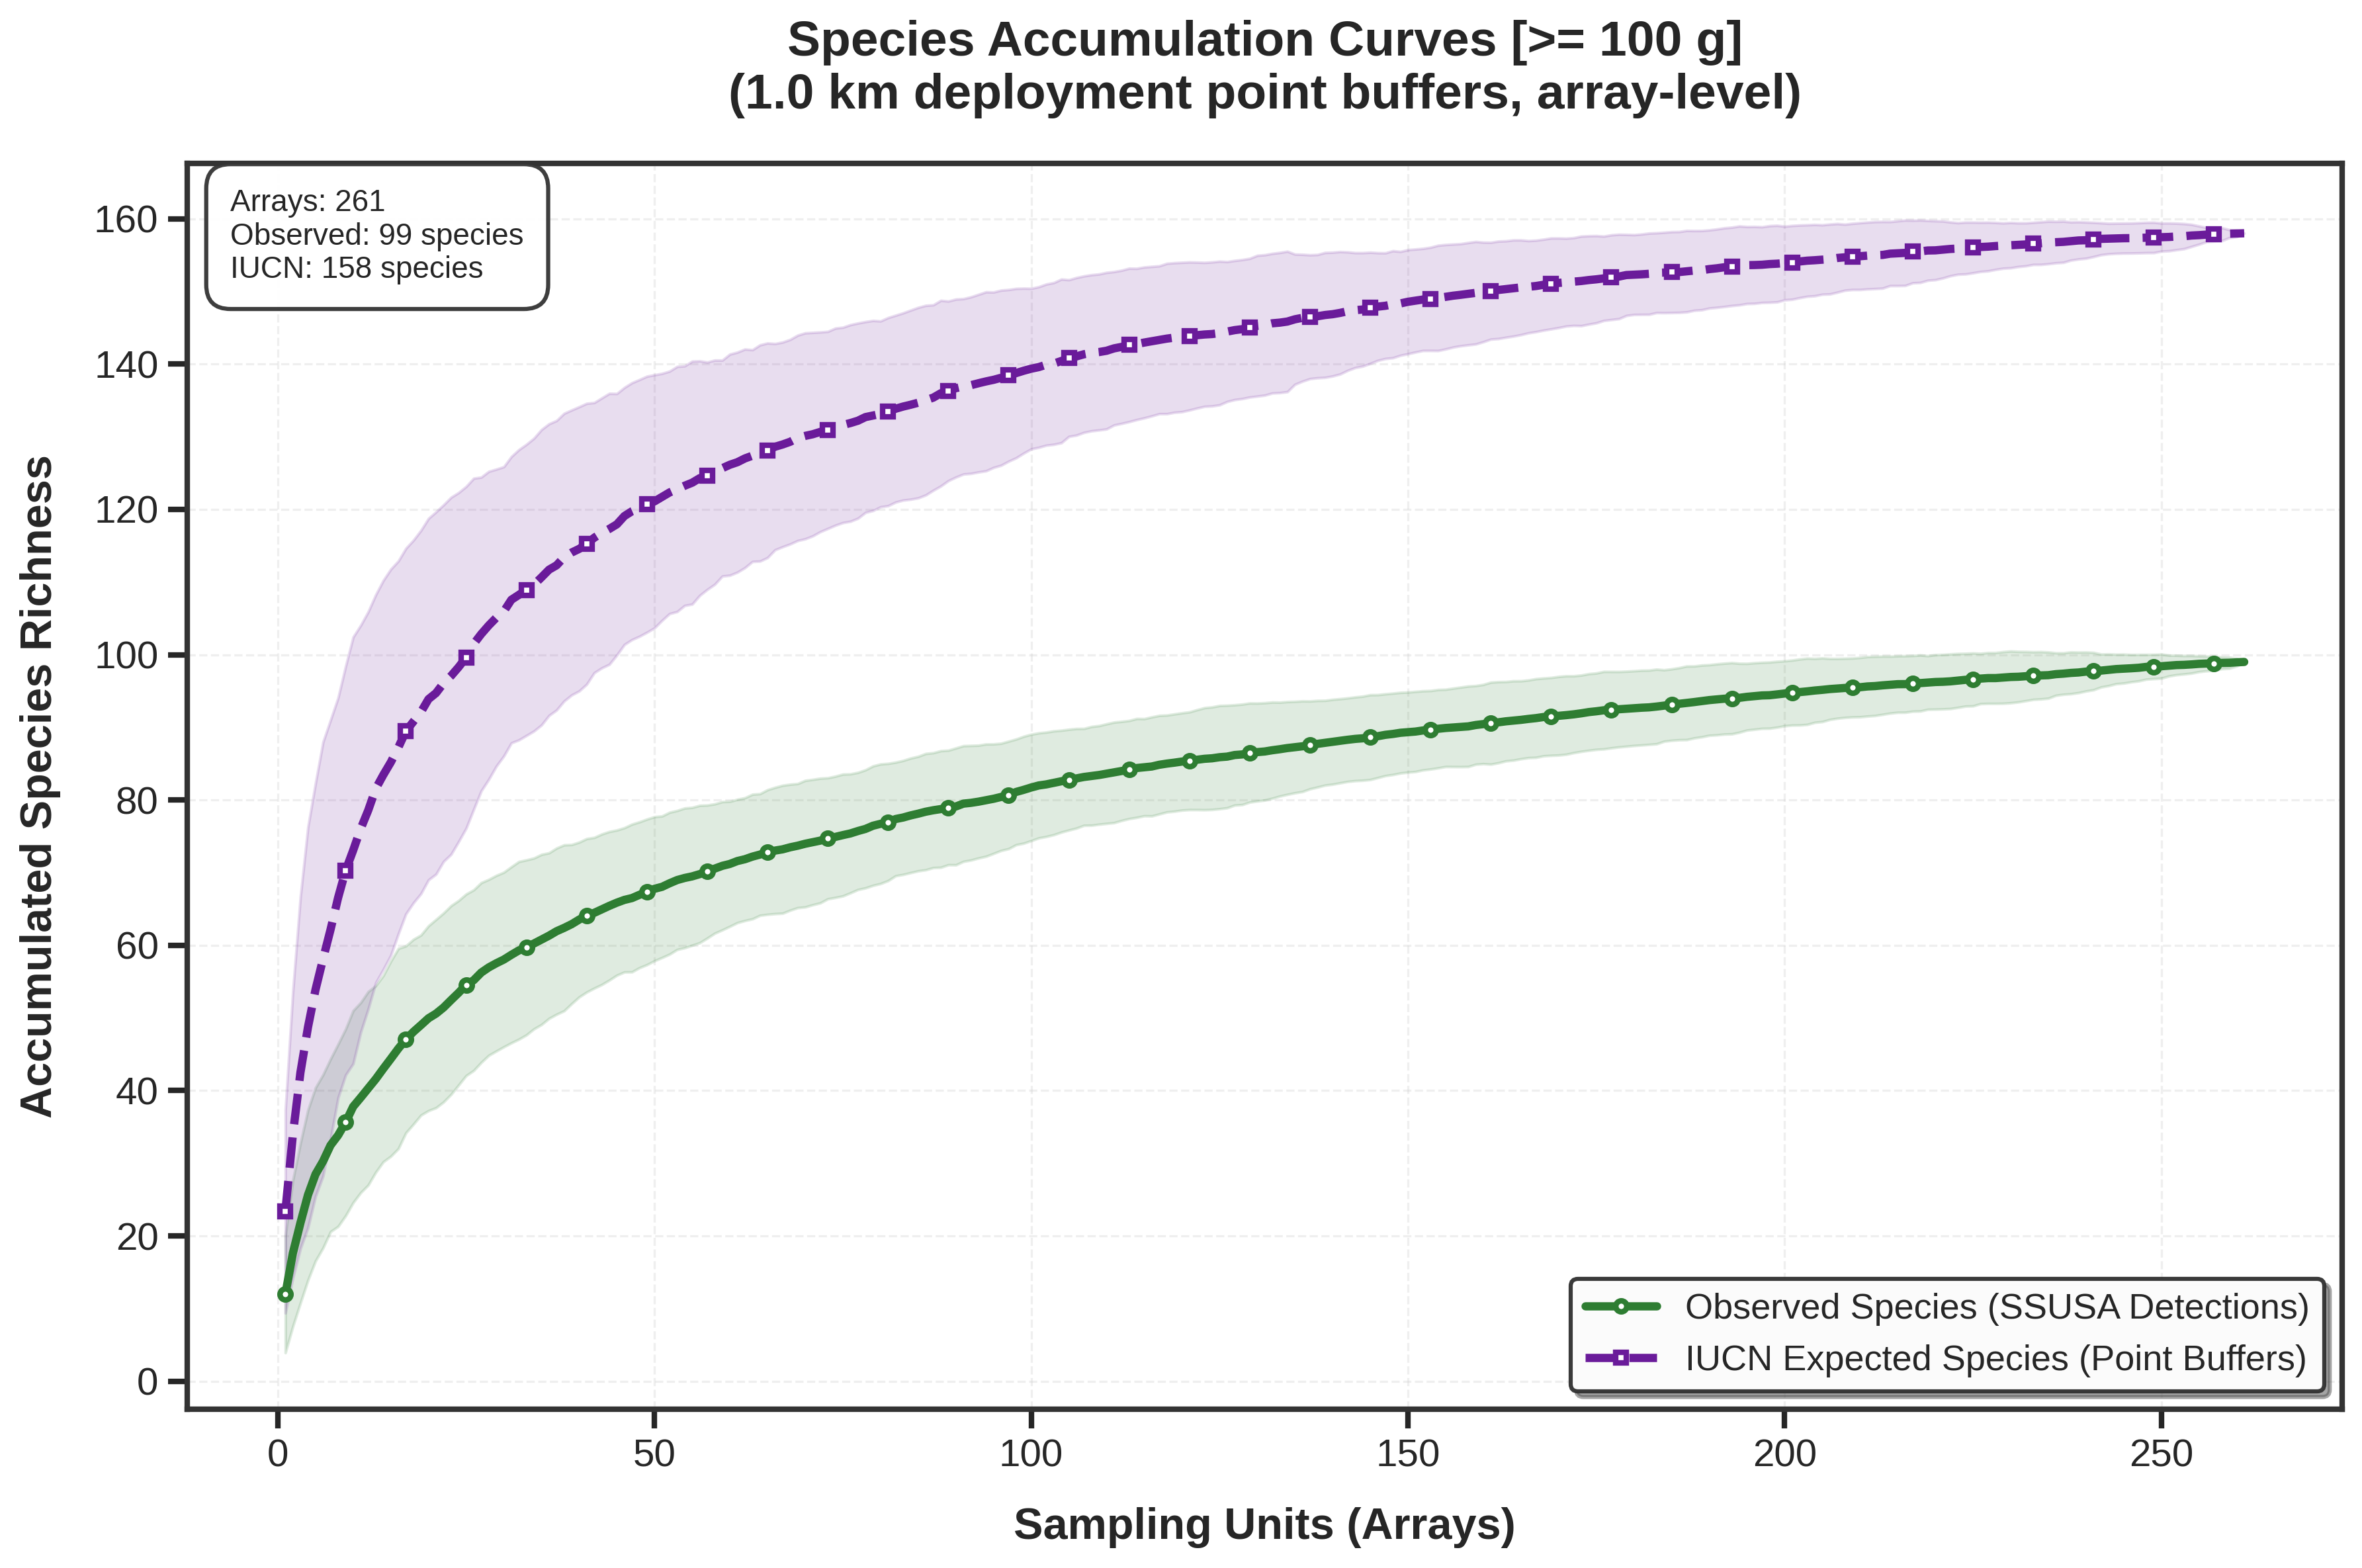


  Observed richness : 99
  IUCN richness     : 158
  Detection gap     : 59 species

MASS THRESHOLD: >= 1000 g
  Threshold: >= 1000 g
    Retained by mass       : 46
    Retained (mass missing): 63
    Removed (below thresh) : 202
    Total eligible         : 109 / 311

  Global comparison (>= 1000 g):
    both          : 60
    snapshot_only : 7
    iucn_only     : 42


,species,in_snapshot,in_iucn,category
0,alces alces,True,True,both
1,antilocapra americana,True,True,both
2,bassariscus astutus,True,True,both
3,callospermophilus lateralis,True,True,both
4,canis latrans,True,True,both
...,...,...,...,...
104,urocitellus canus,False,True,iucn_only
105,urocitellus columbianus,False,True,iucn_only
106,urocitellus elegans,False,True,iucn_only
107,urocitellus mollis,False,True,iucn_only


  Saved to ../data/ssusa/global_comparison_1000g.csv

  Observed matrix : 261 arrays x 67 species
  IUCN matrix     : 261 arrays x 102 species


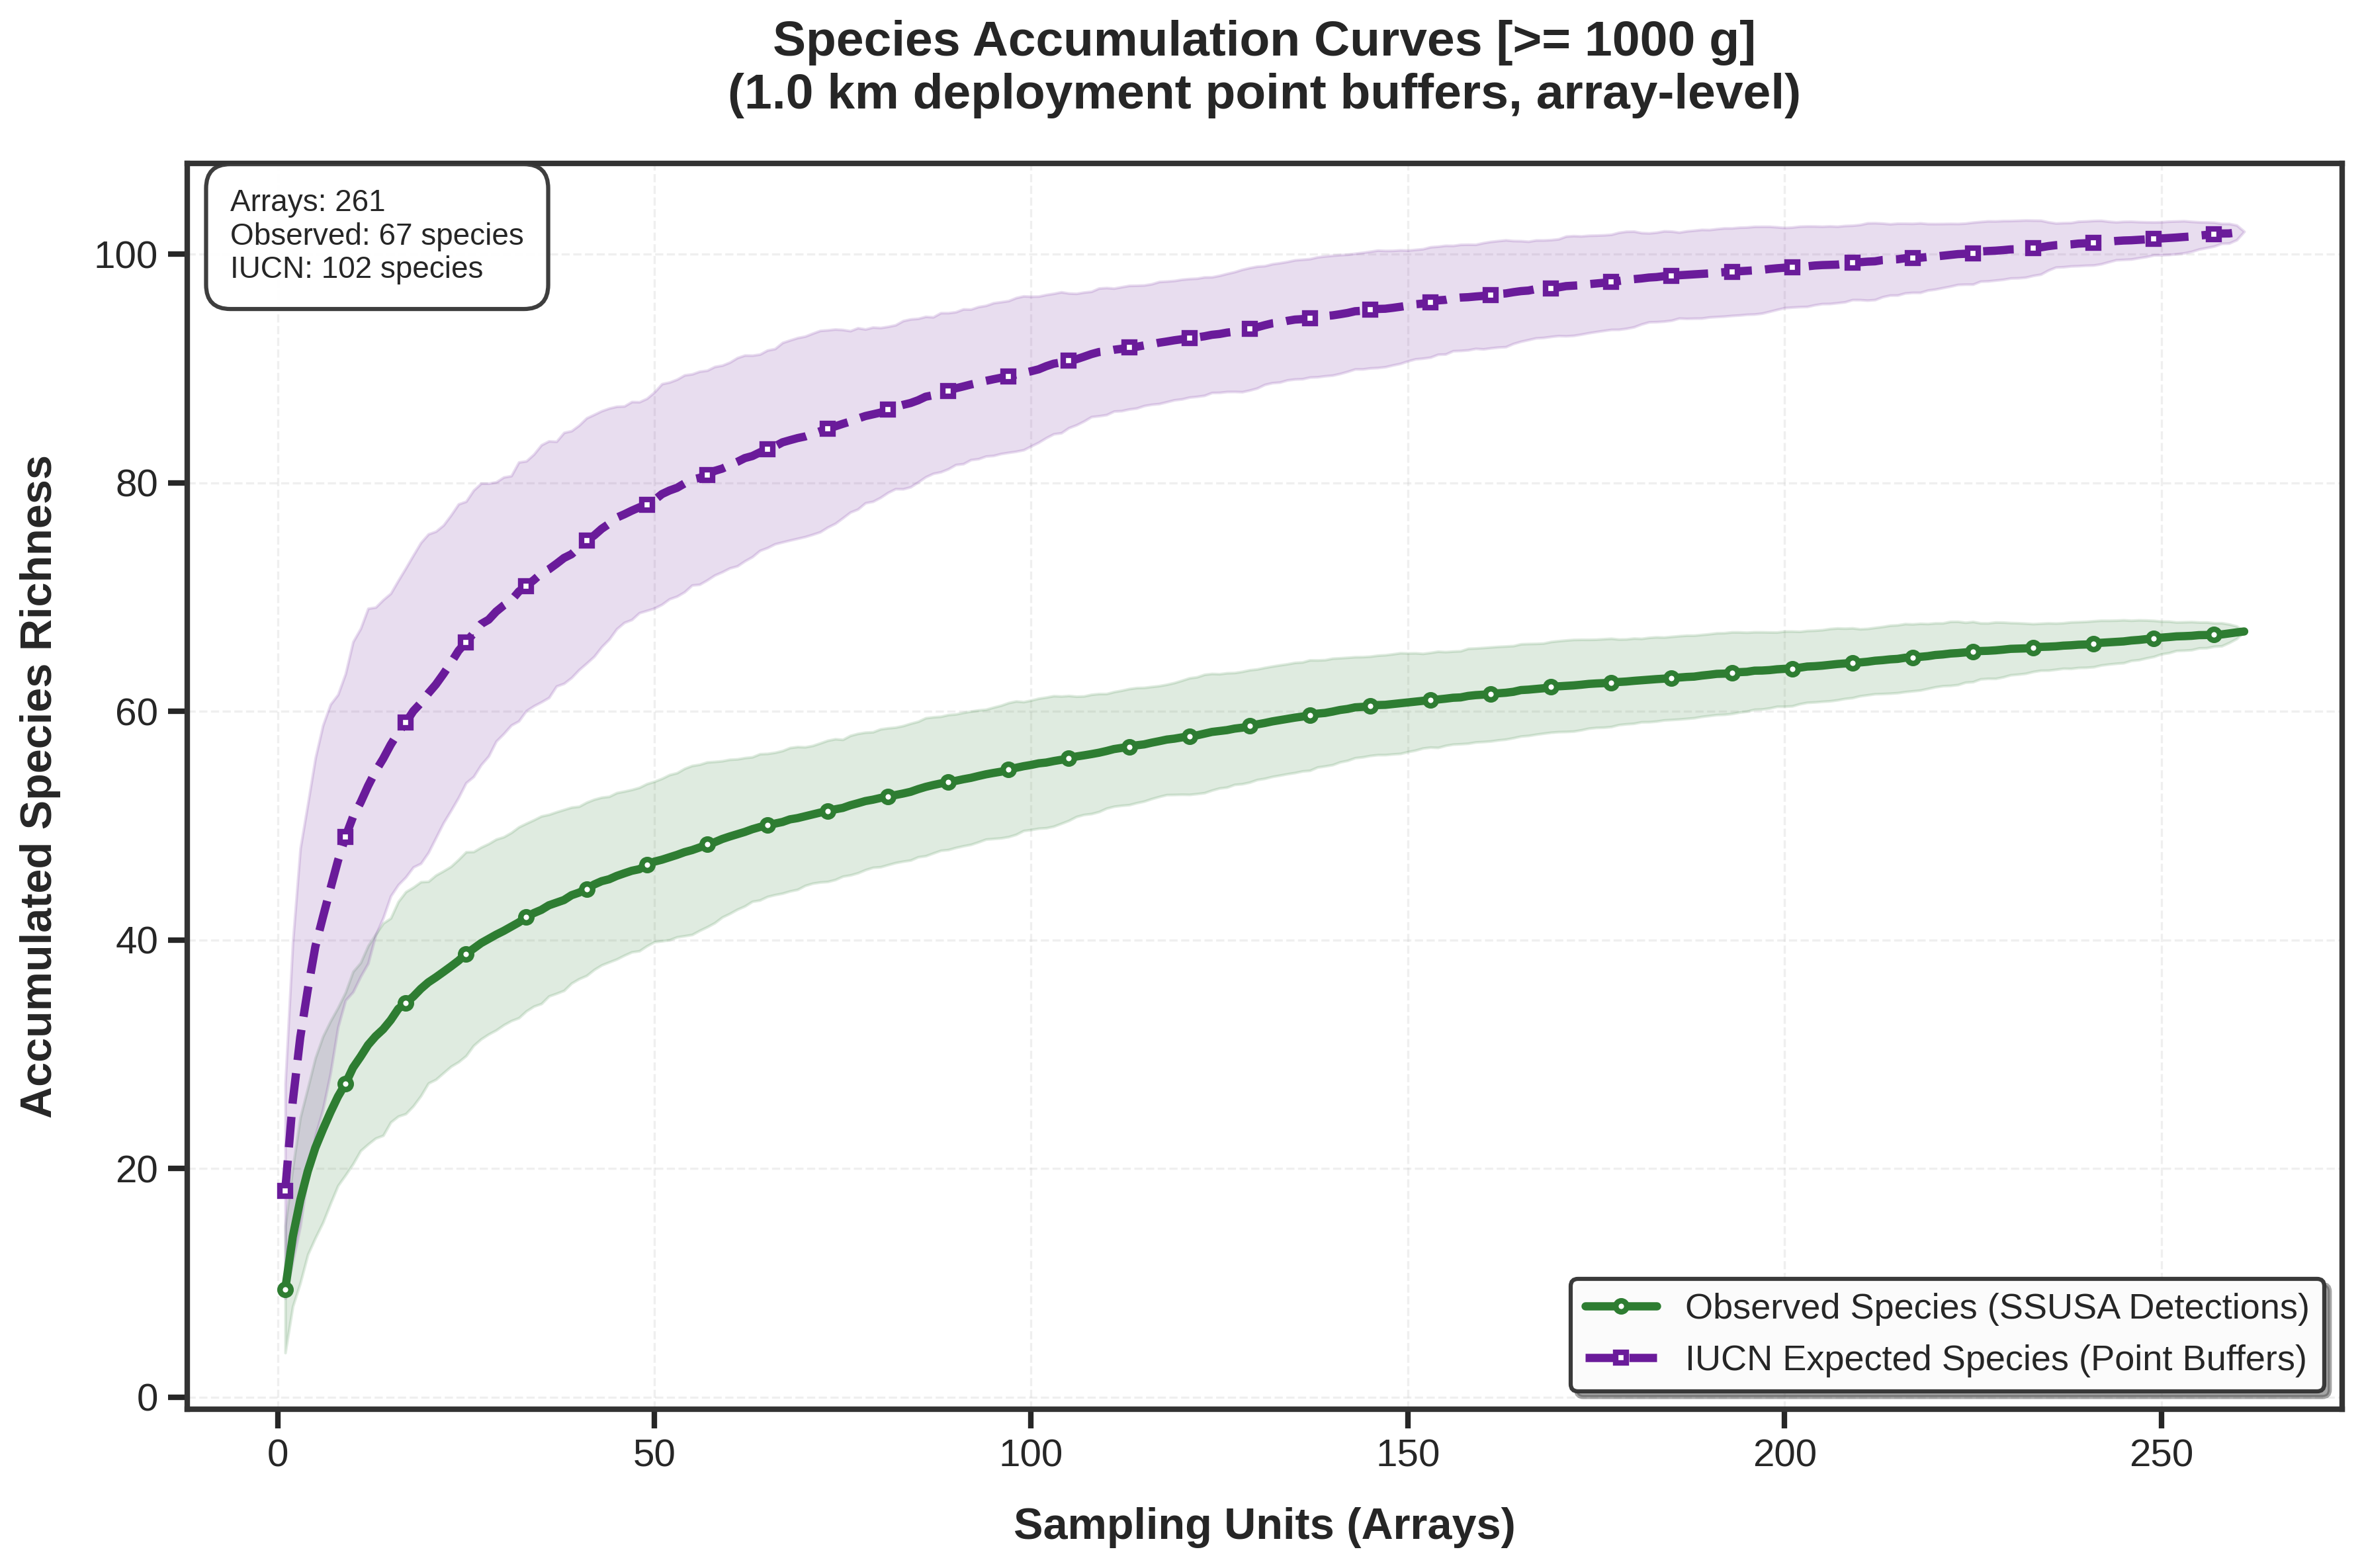


  Observed richness : 67
  IUCN richness     : 102
  Detection gap     : 35 species


In [18]:
# ==============================================================================
# Mass-Threshold Analysis Loop
# ==============================================================================
results_summary = []
curve_results = []

all_snapshot_species = set(df_points['Sci_Name'].dropna().unique())
all_iucn_species = set(iucn_in_point_buffers['Sci_Name'].dropna().unique())
all_species = all_snapshot_species | all_iucn_species
n_units = len(all_arrays)

for threshold in mass_thresholds:
    label = threshold_label(threshold)
    print("\n" + "=" * 70)
    print(f"MASS THRESHOLD: {label}")
    print("=" * 70)

    eligible = get_eligible_species(threshold, all_species, pantheria)

    # ---- Filter SSUSA observations first ----
    df_filtered = df_points[df_points['Sci_Name'].isin(eligible)].copy()

    # ---- Filter IUCN deployment-buffer hits with the same rule ----
    iucn_pb_filtered = iucn_in_point_buffers[
        iucn_in_point_buffers['Sci_Name'].isin(eligible)
    ].copy()

    # ------------------------------------------------------------------
    # Global comparison table
    # ------------------------------------------------------------------
    global_joint = build_global_comparison(df_filtered, iucn_pb_filtered, species_col='Sci_Name')
    cat_counts = global_joint['category'].value_counts() if not global_joint.empty else pd.Series(dtype=int)

    print(f"\n  Global comparison ({label}):")
    print(f"    both          : {cat_counts.get('both', 0)}")
    print(f"    snapshot_only : {cat_counts.get('snapshot_only', 0)}")
    print(f"    iucn_only     : {cat_counts.get('iucn_only', 0)}")
    display(global_joint)

    out_csv = os.path.join(save_dir, f"global_comparison_{threshold_filesafe(threshold)}.csv")
    global_joint.to_csv(out_csv, index=False)
    print(f"  Saved to {out_csv}")

    # ------------------------------------------------------------------
    # Array-level presence/absence matrices
    # ------------------------------------------------------------------
    mat_obs = get_species_matrix(
        df_filtered,
        unit_col=array_col,
        species_col='Sci_Name',
        all_units=all_arrays,
    )
    mat_iucn = get_species_matrix(
        iucn_pb_filtered,
        unit_col=array_col,
        species_col='Sci_Name',
        all_units=all_arrays,
    )

    n_sp_obs = mat_obs.shape[1]
    n_sp_iucn = mat_iucn.shape[1]

    print(f"\n  Observed matrix : {n_units} arrays x {n_sp_obs} species")
    print(f"  IUCN matrix     : {n_units} arrays x {n_sp_iucn} species")

    summary_row = {
        'Threshold': label,
        'Arrays': n_units,
        'Eligible Species': len(eligible),
        'Observed Species': n_sp_obs,
        'IUCN Species': n_sp_iucn,
        'Both': int(cat_counts.get('both', 0)),
        'Snapshot Only': int(cat_counts.get('snapshot_only', 0)),
        'IUCN Only': int(cat_counts.get('iucn_only', 0)),
        'Detection Gap': int(n_sp_iucn - n_sp_obs),
    }

    # ------------------------------------------------------------------
    # Species Accumulation Curves
    # ------------------------------------------------------------------
    if n_units < 2 or n_sp_obs < 1 or n_sp_iucn < 1:
        print('  ** Not enough data for SAC -- skipping this threshold figure.')
        results_summary.append(summary_row)
        continue

    acc_obs = species_accumulation(mat_obs, method='random', permutations=sac_permutations)
    acc_iucn = species_accumulation(mat_iucn, method='random', permutations=sac_permutations)

    plot_threshold_sac(
        acc_obs,
        acc_iucn,
        n_units=n_units,
        n_sp_obs=n_sp_obs,
        n_sp_iucn=n_sp_iucn,
        label=label,
        buffer_km=point_buffer_km,
    )

    curve_results.append({
        'threshold': threshold,
        'label': label,
        'n_units': n_units,
        'acc_obs': acc_obs,
        'acc_iucn': acc_iucn,
    })
    results_summary.append(summary_row)

COMBINED THRESHOLD OVERLAY


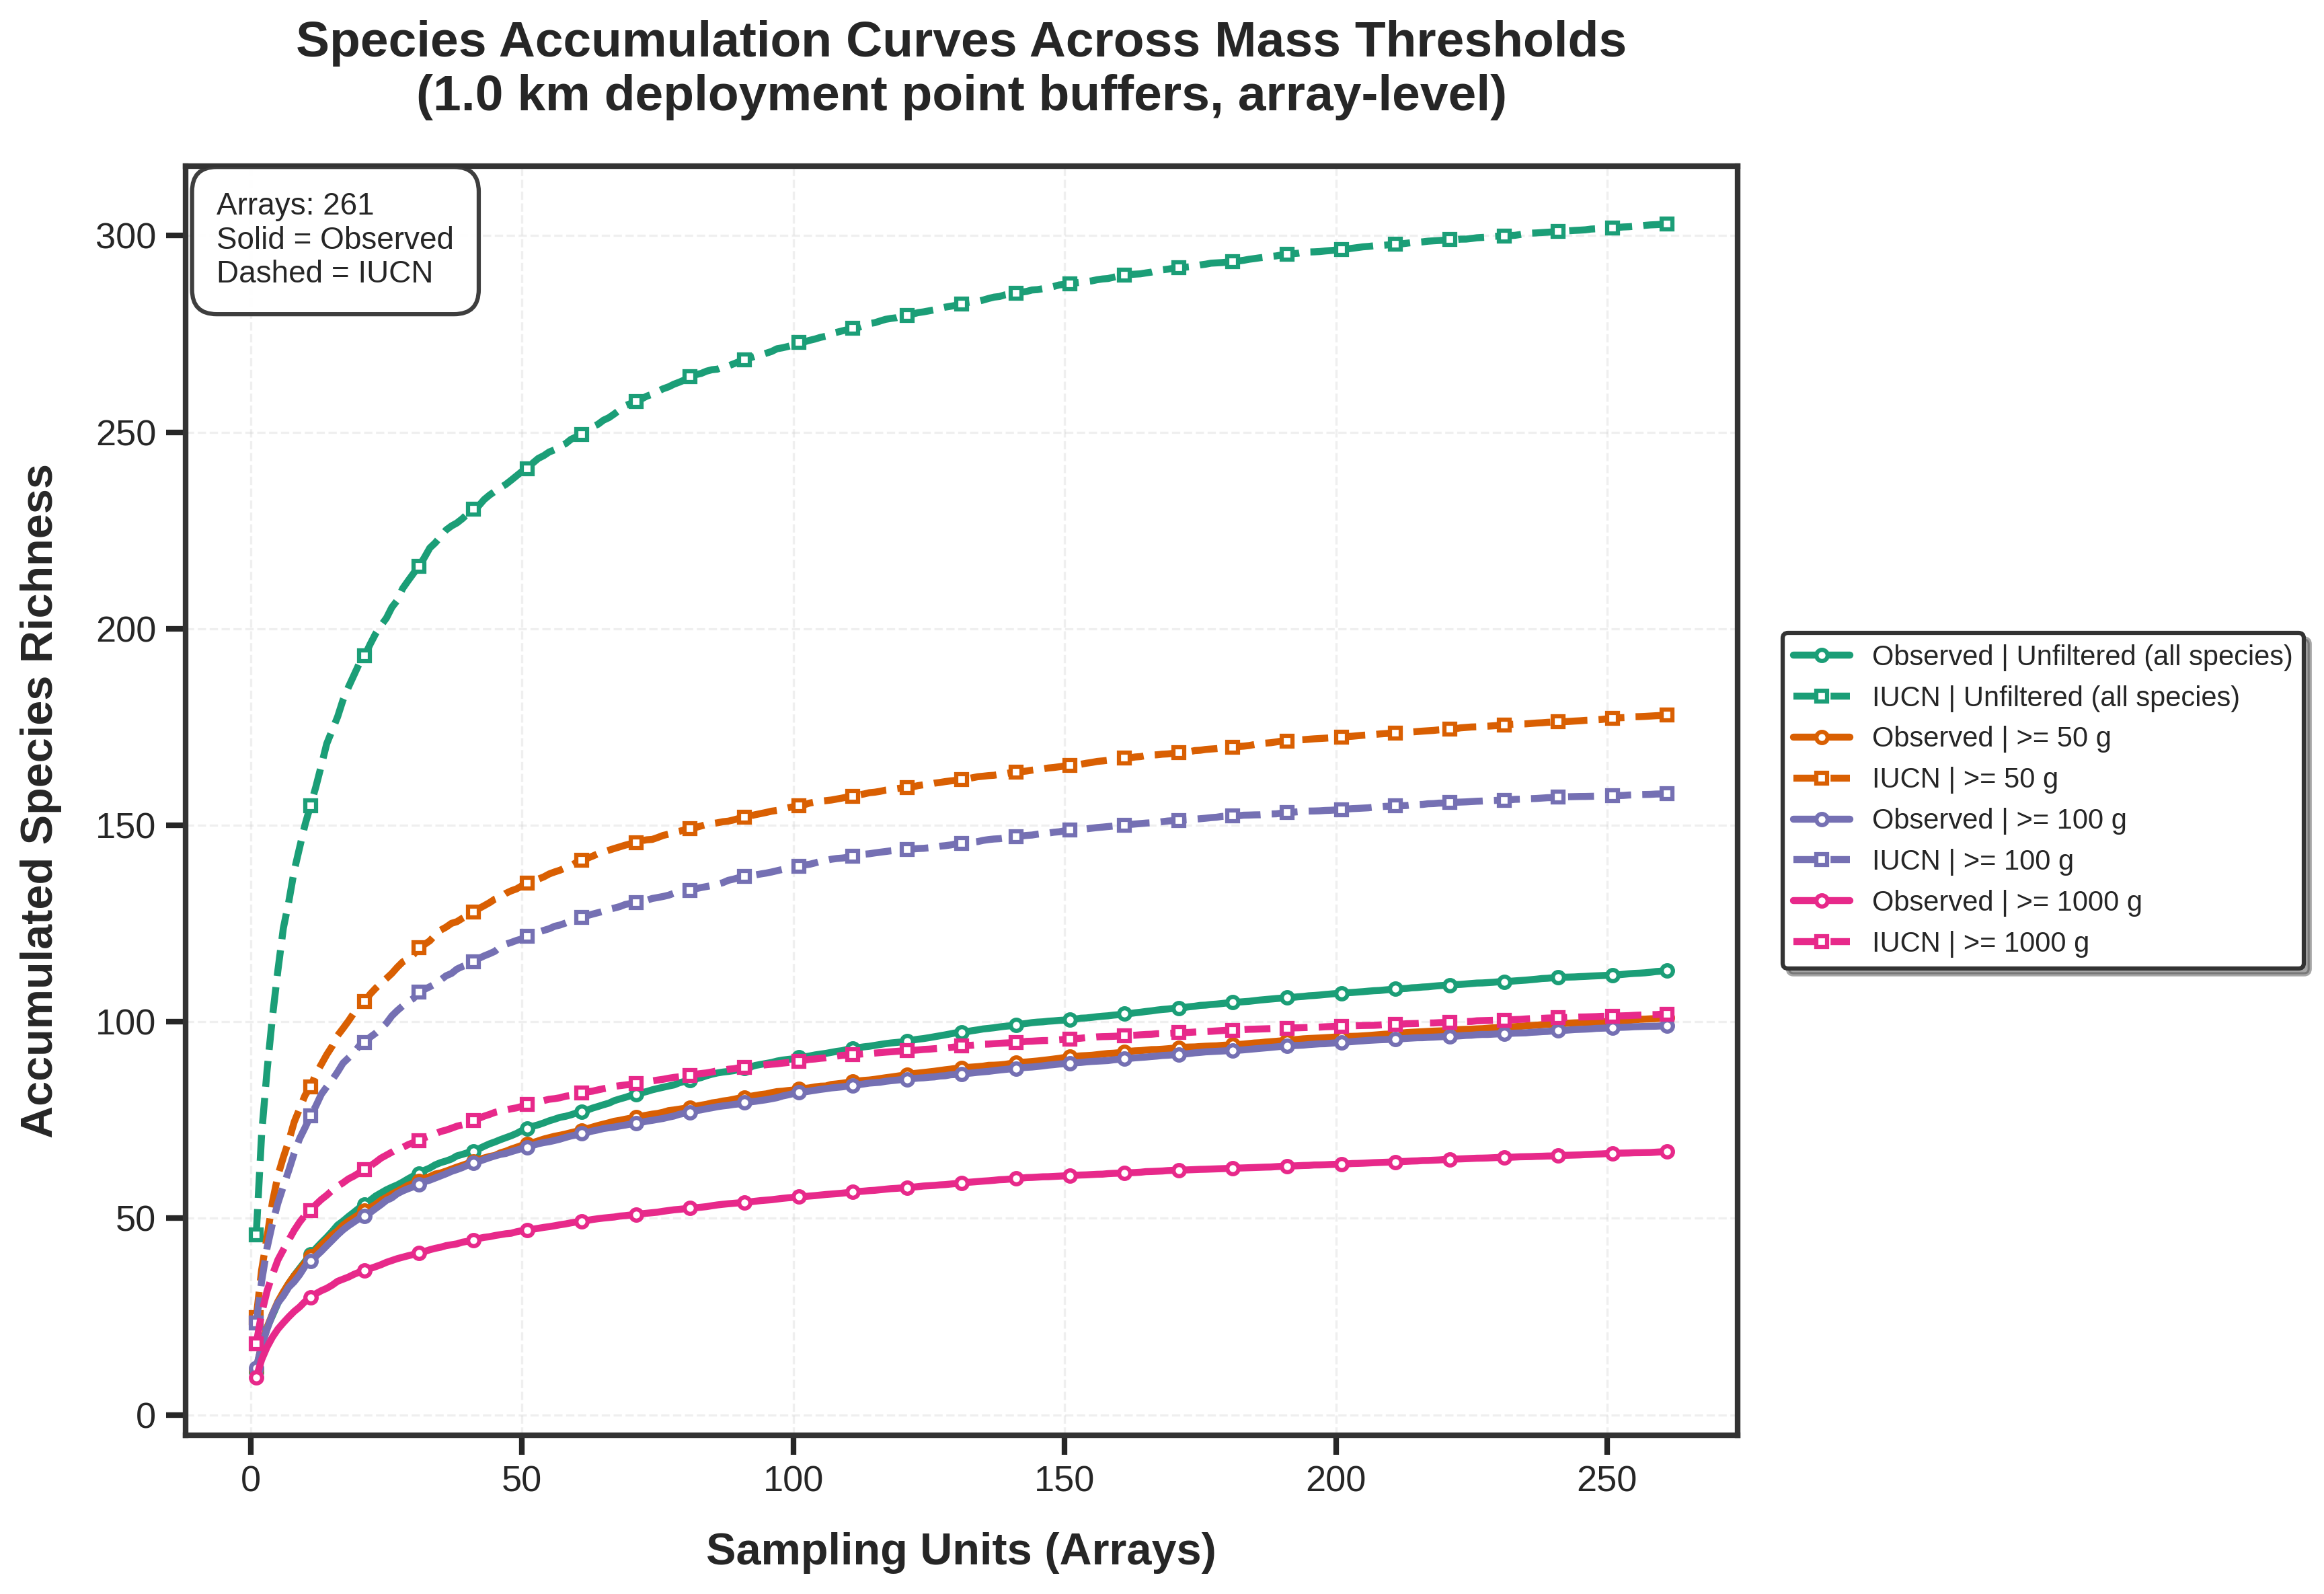

CROSS-THRESHOLD SUMMARY


,Threshold,Arrays,Eligible Species,Observed Species,IUCN Species,Both,Snapshot Only,IUCN Only,Detection Gap
0,Unfiltered (all species),261,311,113,303,105,8,198,190
1,>= 50 g,261,186,101,178,93,8,85,77
2,>= 100 g,261,166,99,158,91,8,67,59
3,>= 1000 g,261,109,67,102,60,7,42,35


In [19]:
# ==============================================================================
# Combined Threshold Overlay + Cross-Threshold Summary
# ==============================================================================
print('=' * 80)
print('COMBINED THRESHOLD OVERLAY')
print('=' * 80)
if curve_results:
    plot_threshold_overlay(curve_results, point_buffer_km)
else:
    print('No SAC curves were available for the combined overlay plot.')

summary_df = pd.DataFrame(results_summary)
print('=' * 80)
print('CROSS-THRESHOLD SUMMARY')
print('=' * 80)
if summary_df.empty:
    print('No threshold results were collected.')
else:
    display(summary_df)